#  Modélisation — Détection de Fraude Bancaire
**Objectif :** Entraîner et comparer plusieurs modèles ML.

In [1]:
# 📦 Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

sns.set_theme(style="whitegrid")
print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [2]:
# 📂 Chargement et préparation des données
df = pd.read_csv(r'C:\Users\emman\Documents\Portfolio\fraud-detection-ml\data\creditcard.csv')

# Feature Engineering
df['Hour']          = (df['Time'] / 3600) % 24
df['Amount_Log']    = np.log1p(df['Amount'])

# Séparation X et y
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount']  = scaler.transform(X_test[['Amount']])

# SMOTETomek
print("⏳ SMOTETomek en cours...")
smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(
    X_train_scaled, y_train
)
print(f"✅ Données prêtes !")
print(f"   Train : {X_train_resampled.shape[0]:,} lignes")
print(f"   Test  : {X_test_scaled.shape[0]:,} lignes")

⏳ SMOTETomek en cours...
✅ Données prêtes !
   Train : 454,902 lignes
   Test  : 56,962 lignes


In [4]:
# Model 1 : Régression Logistique (Baseline)
print("Entraînement de la Régression Logistique...")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000        # Nombre maximum d'itérations
)

lr_model.fit(X_train_resampled, y_train_resampled)

print("Modèle entraîné !")

Entraînement de la Régression Logistique...
Modèle entraîné !


📊 RÉGRESSION LOGISTIQUE — Résultats

🎯 AUC-ROC Score : 0.9706

📋 Rapport de classification :
              precision    recall  f1-score   support

     Normale       1.00      0.97      0.99     56864
      Fraude       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.98     56962



C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2676328499.py:24: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2676328499.py:25: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.savefig('../reports/04_confusion_matrix_lr.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


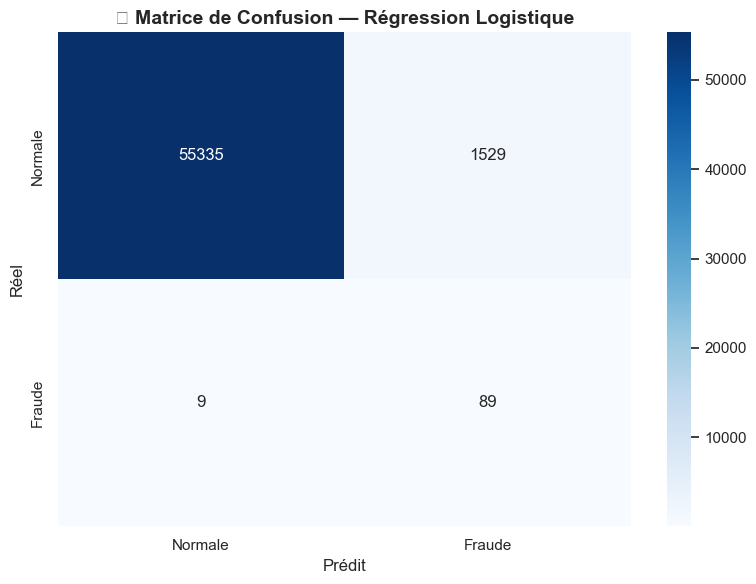

In [5]:
# 📊 Évaluation — Régression Logistique
y_pred_lr    = lr_model.predict(X_test_scaled)
y_proba_lr   = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr       = roc_auc_score(y_test, y_proba_lr)

print("=" * 50)
print("📊 RÉGRESSION LOGISTIQUE — Résultats")
print("=" * 50)
print(f"\n🎯 AUC-ROC Score : {auc_lr:.4f}")
print(f"\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_lr,
      target_names=['Normale', 'Fraude']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normale', 'Fraude'],
            yticklabels=['Normale', 'Fraude'])
plt.title('🔵 Matrice de Confusion — Régression Logistique',
          fontsize=14, fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../reports/04_confusion_matrix_lr.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 🌲 Modèle 2 : Random Forest
print("Entraînement du Random Forest...")
print("(Cela peut prendre 3-5 minutes)\n")

rf_model = RandomForestClassifier(
    n_estimators=100,    # Nombre d'arbres
    random_state=42,
    n_jobs=-1             # Utilise tous les processeurs
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest entraîné !")

Entraînement du Random Forest...
(Cela peut prendre 3-5 minutes)

Random Forest entraîné !


📊 RANDOM FOREST — Résultats

🎯 AUC-ROC Score : 0.9721

📋 Rapport de classification :
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00     56864
      Fraude       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\emman\AppData\Local\Temp\ipykernel_9636\4185005744.py:24: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\4185005744.py:25: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  plt.savefig('../reports/05_confusion_matrix_rf.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


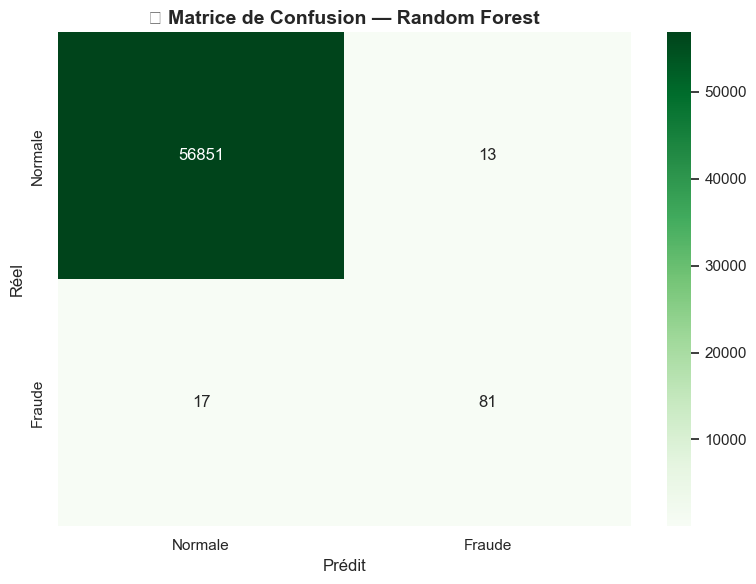

In [9]:
# 📊 Évaluation — Random Forest
y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
auc_rf     = roc_auc_score(y_test, y_proba_rf)

print("=" * 50)
print("📊 RANDOM FOREST — Résultats")
print("=" * 50)
print(f"\n🎯 AUC-ROC Score : {auc_rf:.4f}")
print(f"\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_rf,
      target_names=['Normale', 'Fraude']))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normale', 'Fraude'],
            yticklabels=['Normale', 'Fraude'])
plt.title('🌲 Matrice de Confusion — Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../reports/05_confusion_matrix_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ⚡ Modèle 3 : XGBoost
print("⏳ Entraînement de XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,     # Nombre d'arbres
    learning_rate=0.1,    # Vitesse d'apprentissage
    max_depth=6,          # Profondeur maximale des arbres
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_resampled, y_train_resampled)
print("✅ XGBoost entraîné !")

⏳ Entraînement de XGBoost...
✅ XGBoost entraîné !


📊 XGBOOST — Résultats

🎯 AUC-ROC Score : 0.9782

📋 Rapport de classification :
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00     56864
      Fraude       0.42      0.87      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\emman\AppData\Local\Temp\ipykernel_9636\291450769.py:24: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\291450769.py:25: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.savefig('../reports/06_confusion_matrix_xgb.png',
C:\Users\emman\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


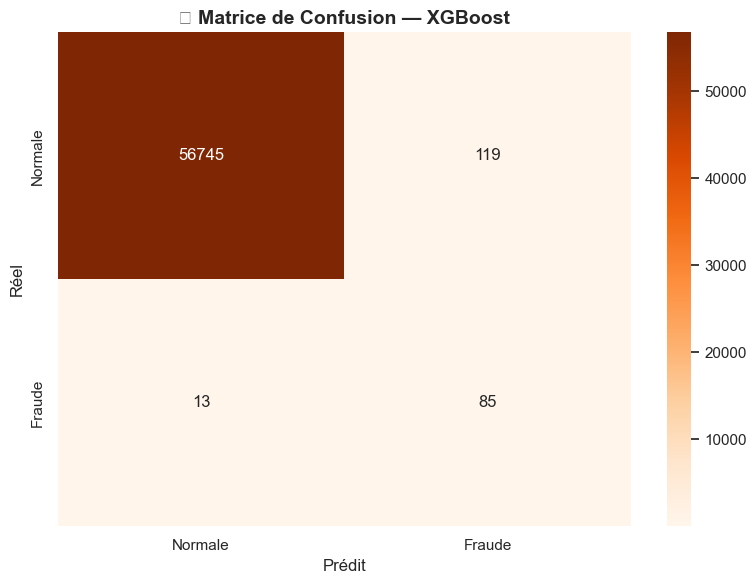

In [11]:
# 📊 Évaluation — XGBoost
y_pred_xgb  = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
auc_xgb     = roc_auc_score(y_test, y_proba_xgb)

print("=" * 50)
print("📊 XGBOOST — Résultats")
print("=" * 50)
print(f"\n🎯 AUC-ROC Score : {auc_xgb:.4f}")
print(f"\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Normale', 'Fraude']))

# Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normale', 'Fraude'],
            yticklabels=['Normale', 'Fraude'])
plt.title('⚡ Matrice de Confusion — XGBoost',
          fontsize=14, fontweight='bold')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../reports/06_confusion_matrix_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()

C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:44: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:44: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:45: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig('../reports/07_comparaison_modeles.png',
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:45: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../reports/07_comparaison_modeles.png',
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\2079193695.py:45: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.sav

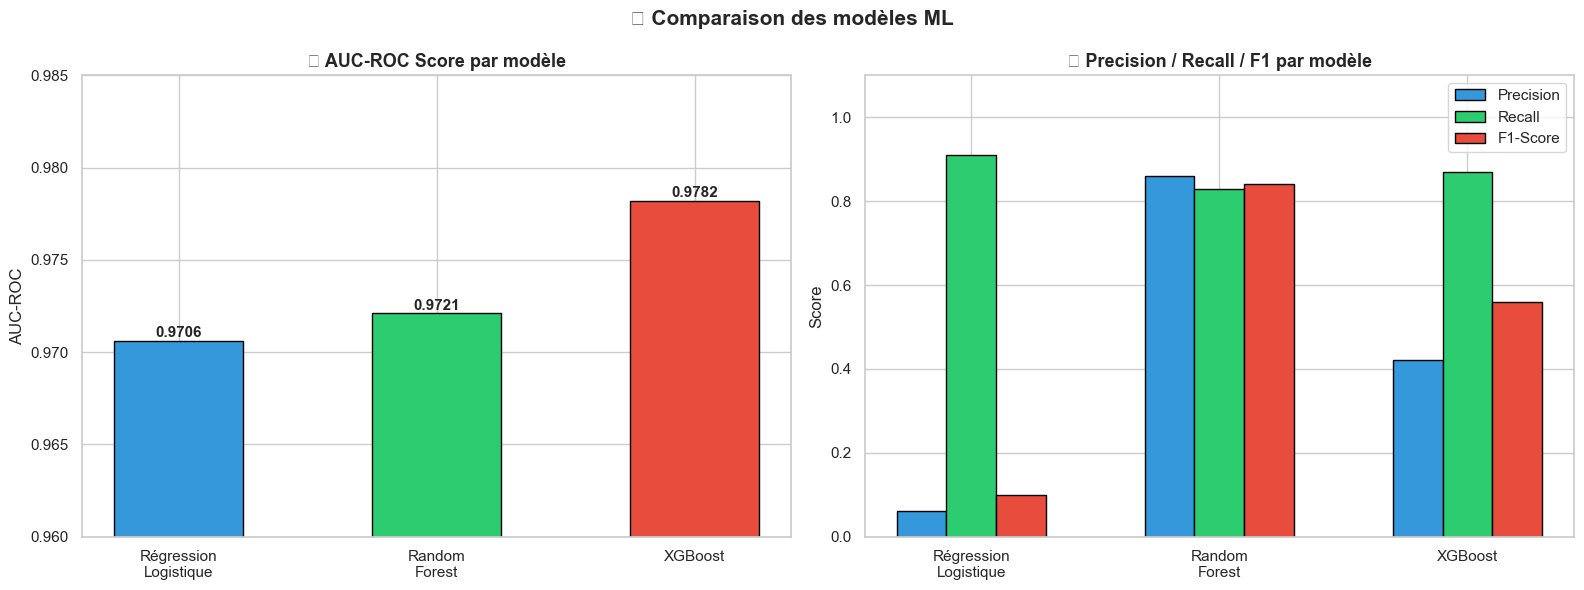

✅ Graphique sauvegardé !


In [12]:
# 📊 Comparaison visuelle des 3 modèles
modeles = ['Régression\nLogistique', 'Random\nForest', 'XGBoost']
auc_scores   = [0.9706, 0.9721, 0.9782]
precision    = [0.06,   0.86,   0.42]
recall       = [0.91,   0.83,   0.87]
f1_scores    = [0.10,   0.84,   0.56]

x      = np.arange(len(modeles))
width  = 0.2
couleurs = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : AUC-ROC ---
bars = axes[0].bar(modeles, auc_scores,
                   color=couleurs, edgecolor='black', width=0.5)
axes[0].set_title('🎯 AUC-ROC Score par modèle',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_ylim(0.96, 0.985)
for bar, score in zip(bars, auc_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{score:.4f}', ha='center',
                 fontweight='bold', fontsize=11)

# --- Graphique 2 : Precision / Recall / F1 ---
axes[1].bar(x - width, precision, width,
            label='Precision', color='#3498db', edgecolor='black')
axes[1].bar(x,          recall,    width,
            label='Recall',    color='#2ecc71', edgecolor='black')
axes[1].bar(x + width,  f1_scores, width,
            label='F1-Score',  color='#e74c3c', edgecolor='black')
axes[1].set_title('📊 Precision / Recall / F1 par modèle',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modeles)
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.suptitle('🏆 Comparaison des modèles ML',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/07_comparaison_modeles.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé !")

C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:47: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:47: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:48: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('../reports/08_courbes_roc.png',
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../reports/08_courbes_roc.png',
C:\Users\emman\AppData\Local\Temp\ipykernel_9636\3636183916.py:48: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Aria

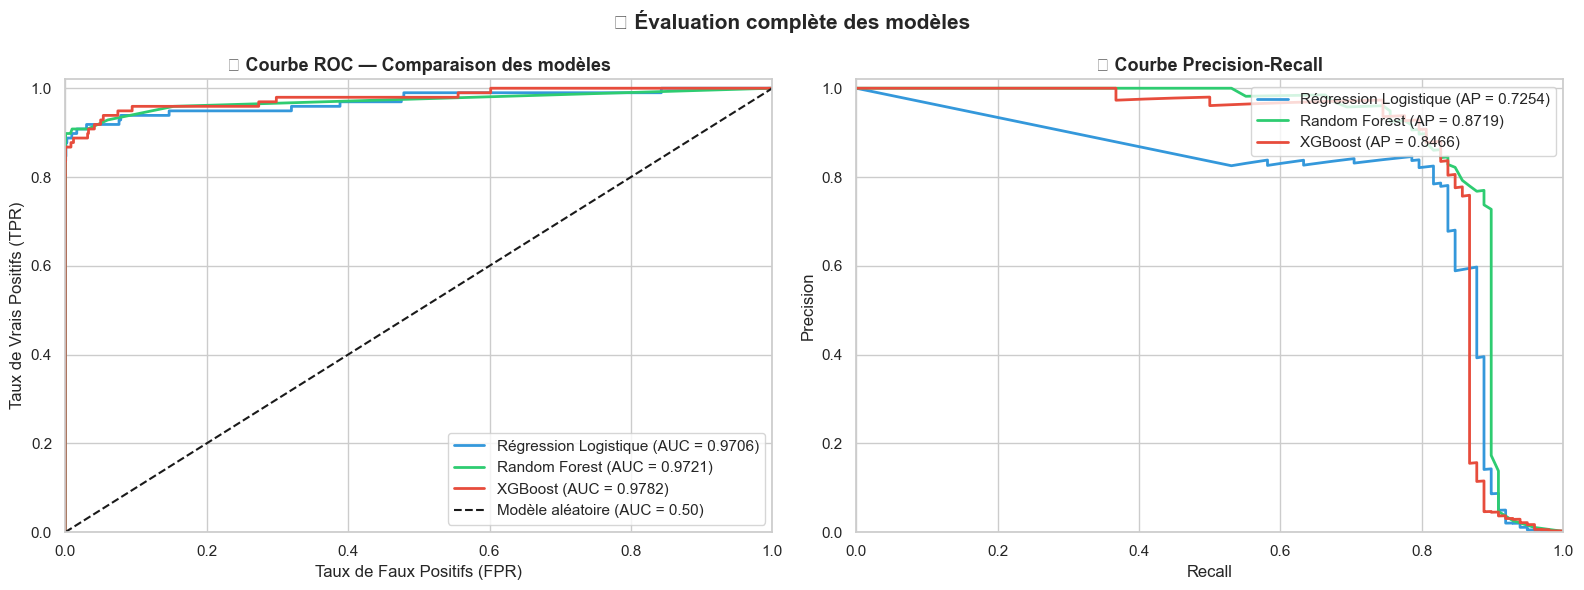

✅ Courbes ROC sauvegardées !


In [13]:
# 📈 Courbe ROC — Comparaison des 3 modèles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Données ROC pour chaque modèle ---
modeles_info = [
    ('Régression Logistique', y_proba_lr,  '#3498db', auc_lr),
    ('Random Forest',         y_proba_rf,  '#2ecc71', auc_rf),
    ('XGBoost',               y_proba_xgb, '#e74c3c', auc_xgb),
]

# --- Graphique 1 : Courbe ROC ---
for nom, proba, couleur, auc in modeles_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=couleur, lw=2,
                 label=f'{nom} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5,
             label='Modèle aléatoire (AUC = 0.50)')
axes[0].set_title('📈 Courbe ROC — Comparaison des modèles',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# --- Graphique 2 : Courbe Precision-Recall ---
for nom, proba, couleur, auc in modeles_info:
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, proba
    )
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall_curve, precision_curve,
                 color=couleur, lw=2,
                 label=f'{nom} (AP = {ap:.4f})')

axes[1].set_title('📊 Courbe Precision-Recall',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('🏆 Évaluation complète des modèles',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_courbes_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes ROC sauvegardées !")